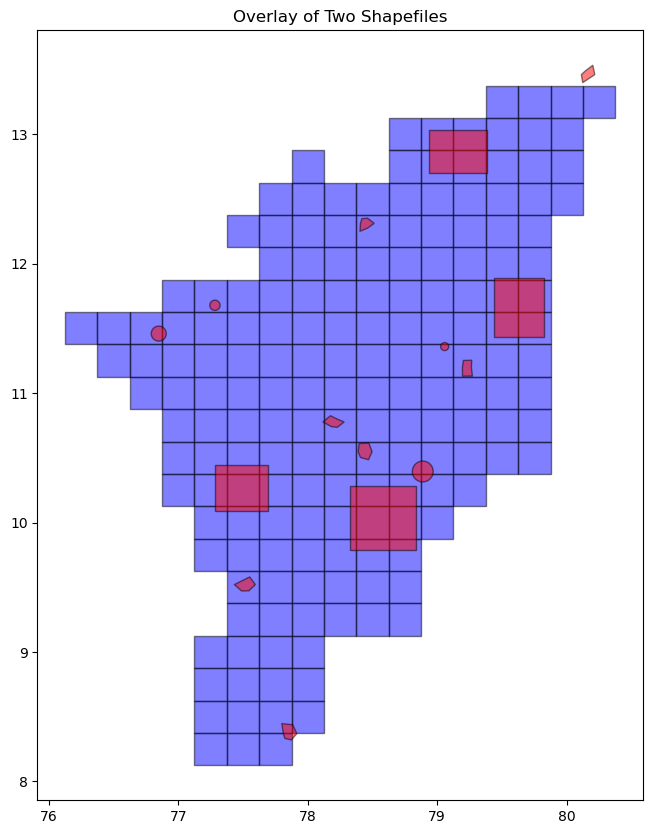

In [28]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load the shapefiles
shapefile1 = gpd.read_file(r"C:\Users\91956\Downloads\Drought and Heatsress\Drought.shp")
state = gpd.read_file(r"C:\Users\91956\Downloads\Random_BGN\random_shapes_tamil_nadu.shp")

# Create a plot with both shapefiles
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the first shapefile
shapefile1.plot(ax=ax, color='blue', alpha=0.5, edgecolor='black')

# Plot the second shapefile (overlay on top of the first one)
state.plot(ax=ax, color='red', alpha=0.5, edgecolor='black')

# Add a title and show the plot
ax.set_title('Overlay of Two Shapefiles')
plt.show()


In [29]:
import geopandas as gpd
import numpy as np

# Load the shapefiles
shapefile1 = gpd.read_file(r"C:\Users\91956\Downloads\Drought and Heatsress\Drought.shp")
state = gpd.read_file(r"C:\Users\91956\Downloads\Random_BGN\random_shapes_tamil_nadu.shp")



# Add a new column for total area of each feature in the state GeoDataFrame
state['total_area'] = state.geometry.area

# Add columns to store the area falling under categories 0 and 1
state['area_under_0'] = 0.0
state['area_under_1'] = 0.0

# Add a column to store the dominant category
state['dominant_category'] = np.nan

# Loop through each feature in the state shapefile
for idx, state_feature in state.iterrows():
    state_geometry = state_feature.geometry
    
    # Initialize area counters for categories 0 and 1
    area_0 = 0.0
    area_1 = 0.0
    
    # Loop through each feature in shapefile1
    for _, shapefile1_feature in shapefile1.iterrows():
        shapefile1_geometry = shapefile1_feature.geometry
        shapefile1_category = shapefile1_feature['value']  # Assuming 'category' column exists
        
        # Calculate the intersection of the state geometry with the shapefile1 geometry
        intersection = state_geometry.intersection(shapefile1_geometry)
        
        if not intersection.is_empty:
            intersection_area = intersection.area
            
            # Add the area to the corresponding category
            if shapefile1_category == 0:
                area_0 += intersection_area
            elif shapefile1_category == 1:
                area_1 += intersection_area
    
    # Update the state GeoDataFrame with the calculated areas
    state.at[idx, 'area_under_0'] = area_0
    state.at[idx, 'area_under_1'] = area_1
    
    # Determine the dominant category
    if area_0 > area_1:
        state.at[idx, 'dominant_category'] = 0
    elif area_1 > area_0:
        state.at[idx, 'dominant_category'] = 1
    else:
        state.at[idx, 'dominant_category'] = None  # If areas are equal, assign None or a default value (e.g., 0)

# Save the updated GeoDataFrame (optional)
state.to_file(r"C:\Users\91956\Downloads\Drought_category.shp")

# Print the updated GeoDataFrame to verify
state

C:\Users\91956\anaconda3\envs\lila\lib\site-packages\shapely\set_operations.py:133: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
C:\Users\91956\anaconda3\envs\lila\lib\site-packages\shapely\set_operations.py:133: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
C:\Users\91956\AppData\Local\Temp\ipykernel_18500\2513089539.py:58: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  state.to_file(r"C:\Users\91956\Downloads\Drought_category.shp")


,FID,geometry,total_area,area_under_0,area_under_1,dominant_category
0,0,"POLYGON ((78.96882 10.39402, 78.96844 10.38613...",0.020332,0.015052,0.005280,0.0
1,1,"POLYGON ((80.21732 13.45926, 80.17557 13.43172...",0.007116,0.000000,0.000000,NaN
2,2,"POLYGON ((77.28691 10.08973, 77.28691 10.44495...",0.145209,0.142103,0.003107,0.0
3,3,"POLYGON ((79.43519 11.43595, 79.43519 11.88478...",0.174736,0.073599,0.101137,1.0
4,4,"POLYGON ((78.51356 12.31070, 78.46075 12.27296...",0.006617,0.000000,0.006617,1.0
5,5,"POLYGON ((77.59547 9.52070, 77.54520 9.47245, ...",0.010124,0.010124,0.000000,0.0
6,6,"POLYGON ((76.90724 11.45902, 76.90696 11.45334...",0.010535,0.008144,0.002390,0.0
7,7,"POLYGON ((78.49723 10.54720, 78.46891 10.48482...",0.010517,0.010517,0.000000,0.0
8,8,"POLYGON ((79.08842 11.35885, 79.08827 11.35581...",0.003022,0.003022,0.000000,0.0
9,9,"POLYGON ((77.32288 11.67768, 77.32268 11.67379...",0.004949,0.000000,0.004949,1.0
